Importing cleaned dataset 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
FILE_PATH = "../../data/01-interim/MxMH_Survey_cleaned.csv"
df = pd.read_csv(FILE_PATH)
df.head()

Matplotlib is building the font cache; this may take a moment.


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [3]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     735 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 735 non-null    float64
 4   While working                 735 non-null    object 
 5   Instrumentalist               735 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     735 non-null    object 
 8   Exploratory                   735 non-null    object 
 9   Foreign languages             735 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         735 non-null    object 
 12  Frequency [Country]           735 non-null    object 
 13  Frequ

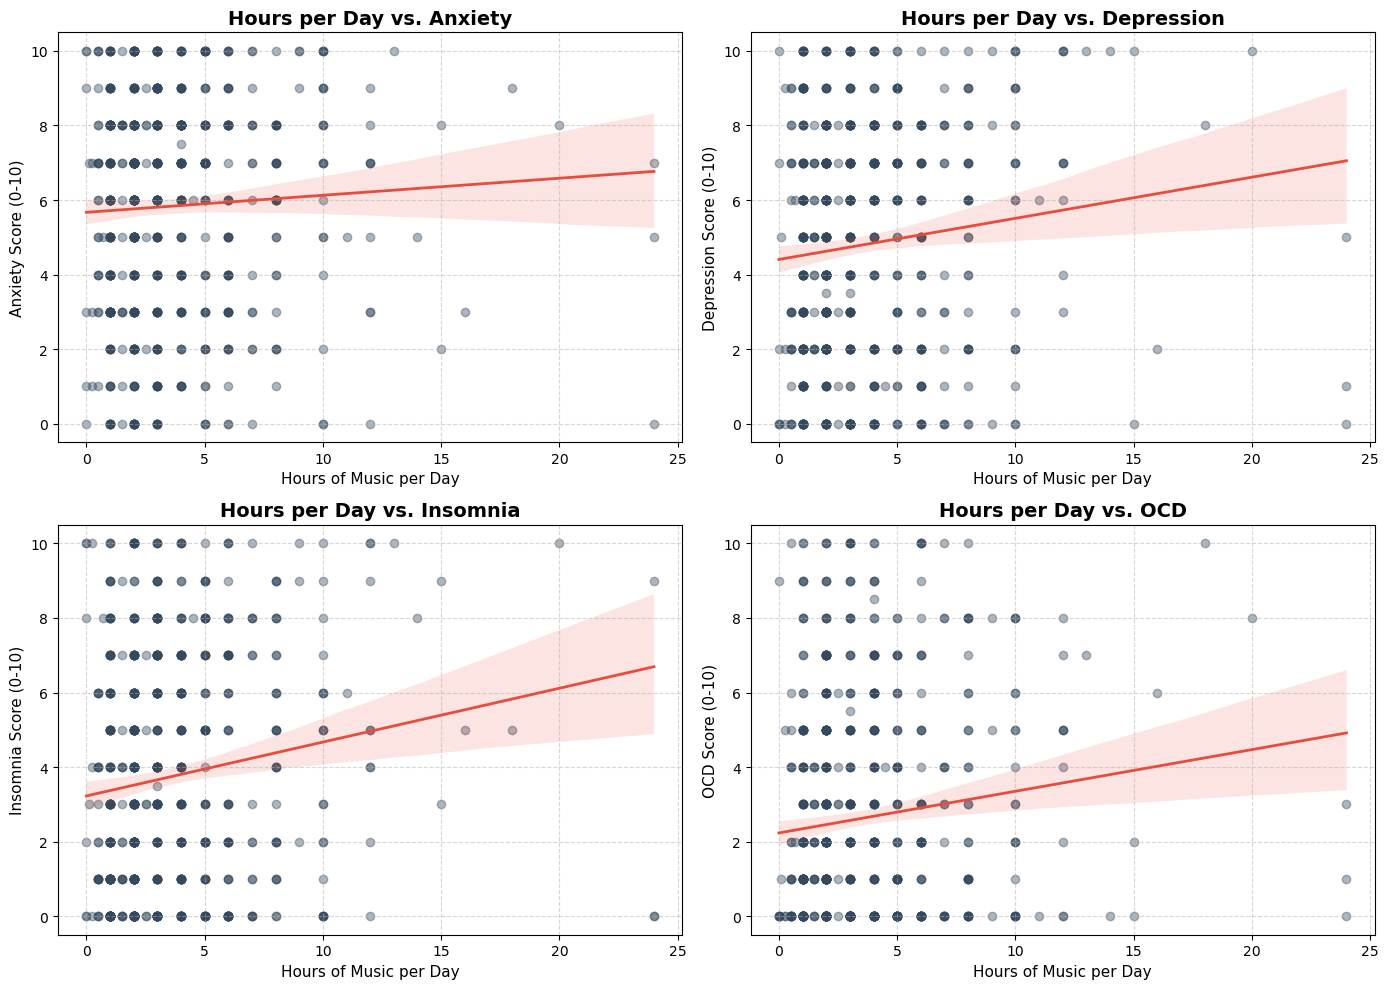

In [4]:
#question to pose: is the amount of time participants listen to music at all related to mental health


# Load the dataset
FILE_PATH = "../../data/01-interim/MxMH_Survey_cleaned.csv"
df = pd.read_csv(FILE_PATH)

# Define the mental health columns to analyze
mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot a regression line for each mental health metric
for i, col in enumerate(mh_columns):
    sns.regplot(
        data=df, 
        x='Hours per day', 
        y=col, 
        ax=axes[i],
        scatter_kws={'alpha': 0.4, 'color': '#34495e'},
        line_kws={'color': '#e74c3c', 'linewidth': 2}
    )
    axes[i].set_title(f'Hours per Day vs. {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Hours of Music per Day', fontsize=11)
    axes[i].set_ylabel(f'{col} Score (0-10)', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Optimize layout to prevent overlapping labels
plt.tight_layout()

# Save the figure
plt.savefig('music_vs_mental_health_trends.png', dpi=300) 

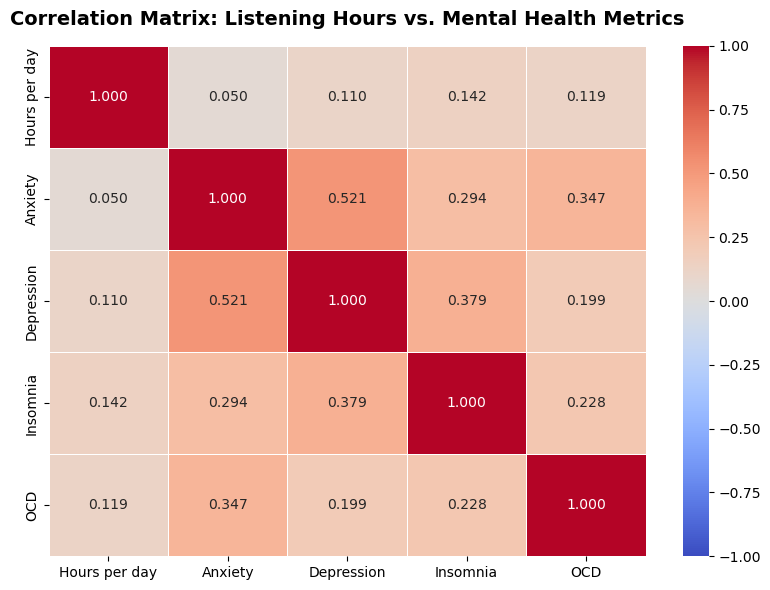

In [5]:

# Select the target columns
target_cols = ['Hours per day', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
corr_matrix = df[target_cols].corr()

# Create the heatmap figure
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    ax=ax
)

plt.title('Correlation Matrix: Listening Hours vs. Mental Health Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Save the figure
plt.savefig('music_vs_mental_health_correlation.png', dpi=300)

// place holder for analysis 


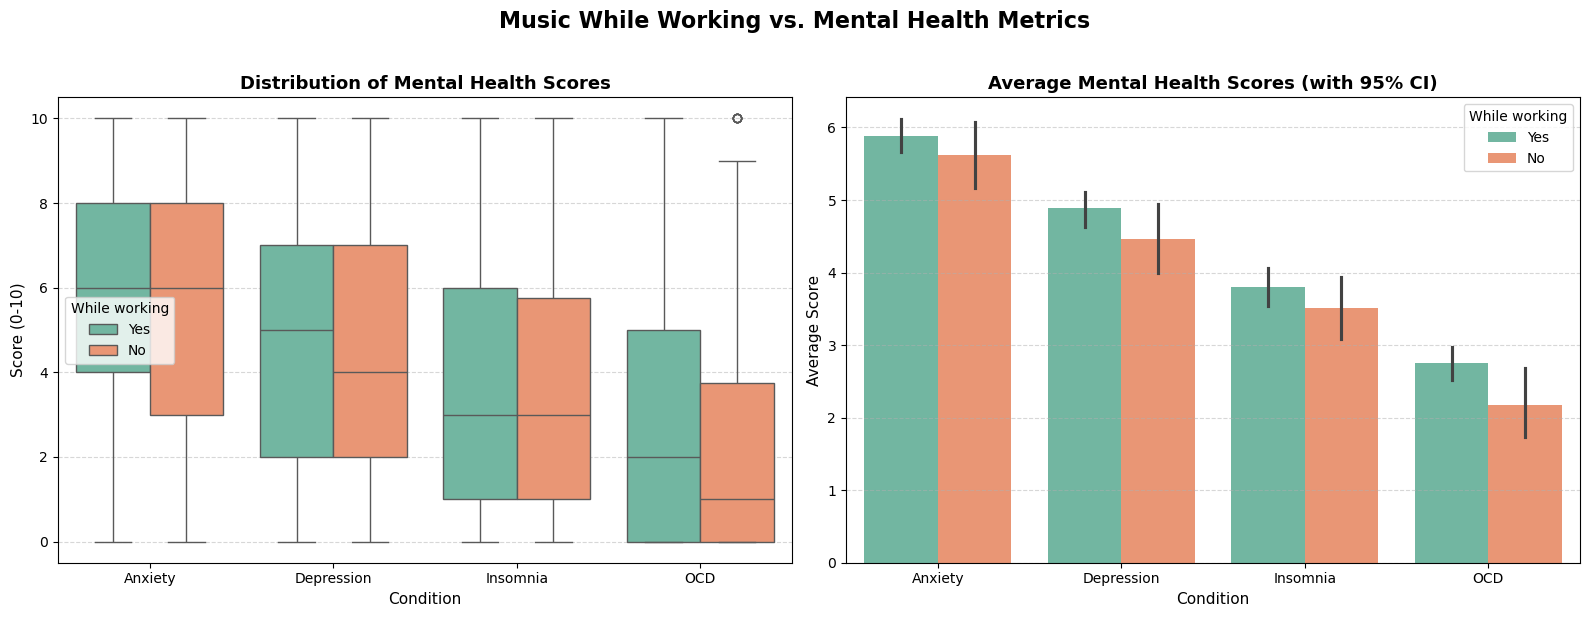

In [7]:
#question to pose: what mental health groups listen to music while working - or better yet which groups do not? is there any coorelation?


# Clean up any missing values in 'While working' just in case
df = df.dropna(subset=['While working'])

# 2. Reshape the data for easier plotting with Seaborn
# This bundles the mental health columns into a single column for the graph to read
mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
df_melted = df.melt(
    id_vars=['While working'], 
    value_vars=mh_columns,
    var_name='Mental Health Metric', 
    value_name='Score'
)

# 3. Setup the visualization canvas (1 row, 2 columns of figures)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Figure A: Boxplot (Shows the entire distribution, medians, and spread) ---
sns.boxplot(
    data=df_melted, 
    x='Mental Health Metric', 
    y='Score', 
    hue='While working', 
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Distribution of Mental Health Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Score (0-10)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Figure B: Bar Plot (Shows the average/mean score with 95% confidence intervals) ---
sns.barplot(
    data=df_melted, 
    x='Mental Health Metric', 
    y='Score', 
    hue='While working', 
    palette='Set2',
    errorbar='ci', # Adds visual error bars to show statistical confidence
    ax=axes[1]
)
axes[1].set_title('Average Mental Health Scores (with 95% CI)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Condition', fontsize=11)
axes[1].set_ylabel('Average Score', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 4. Clean up layout and export
plt.suptitle('Music While Working vs. Mental Health Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the figure to your directory
plt.savefig('working_music_vs_mental_health.png', dpi=300, bbox_inches='tight')

// place holder 2

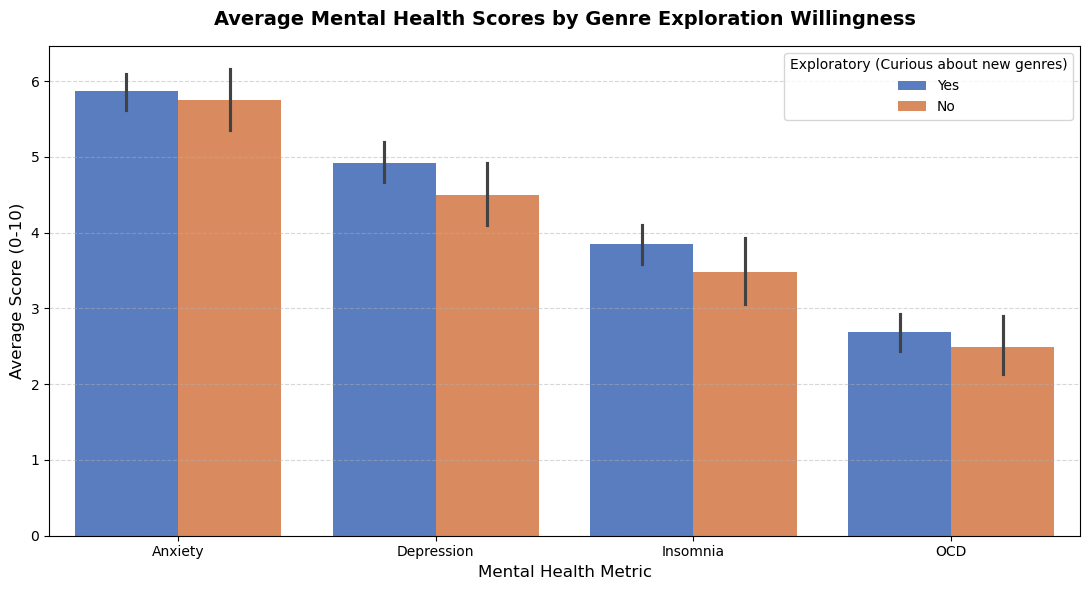

In [8]:
#question to pose which groups of peoiple based upon mental health are willing to explore other genres and are curious to do so?


# Drop missing values in 'Exploratory' if any exist
df = df.dropna(subset=['Exploratory'])

# 2. Reshape the data for side-by-side comparison
mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
df_melted = df.melt(
    id_vars=['Exploratory'], 
    value_vars=mh_columns,
    var_name='Mental Health Metric', 
    value_name='Score'
)

# 3. Create the grouped bar chart
plt.figure(figsize=(11, 6))
sns.barplot(
    data=df_melted,
    x='Mental Health Metric',
    y='Score',
    hue='Exploratory',
    palette='muted',         # Clean, professional color palette
    errorbar='ci'            # Adds 95% confidence intervals to check for significance
)

# 4. Format labels and titles
plt.title('Average Mental Health Scores by Genre Exploration Willingness', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mental Health Metric', fontsize=12)
plt.ylabel('Average Score (0-10)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Exploratory (Curious about new genres)')

# 5. Save the figure
plt.tight_layout()
plt.savefig('genre_exploration_vs_mental_health.png', dpi=300)

the averages actually seem to mask what I really want to look at. I think this is because Anxiety depression and Insomnia are all easeir to both identify and for people to self diagnose. similarly i think less people worldwide struggle with OCD in comparisson to the other groups. So I am instead going to try to graph each seperate

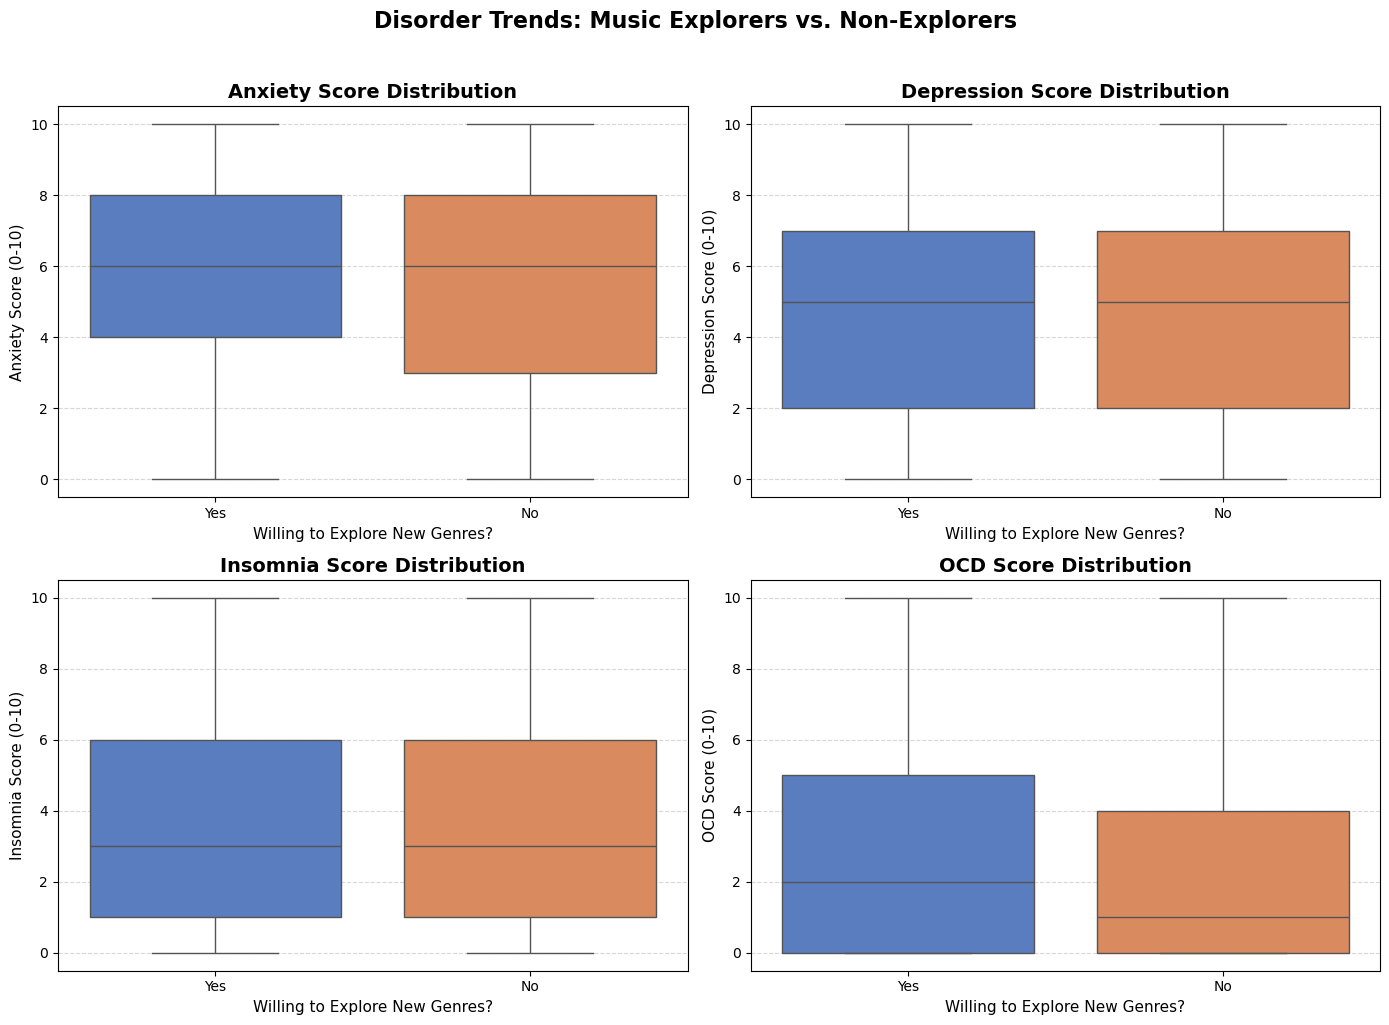

In [9]:
# Clean missing target values
df = df.dropna(subset=['Exploratory'])

# 2. Setup a 2x2 grid for the individual disorders
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flattens the 2D array of axes into a 1D list to loop through easily

# List of the individual mental health scores
mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

# 3. Plot each disorder individually
for i, col in enumerate(mh_columns):
    sns.boxplot(
        data=df, 
        x='Exploratory', 
        y=col, 
        ax=axes[i], 
        palette='muted',
        hue='Exploratory', # Colors the bars based on Yes/No status
        legend=False       # Keeps the layout clean since the X-axis labels are explicit
    )
    
    # Custom titles and labels for every single plot
    axes[i].set_title(f'{col} Score Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Willing to Explore New Genres?', fontsize=11)
    axes[i].set_ylabel(f'{col} Score (0-10)', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# 4. Global layout adjustments and saving
plt.suptitle('Disorder Trends: Music Explorers vs. Non-Explorers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the high-res figure
plt.savefig('individual_disorder_distributions.png', dpi=300, bbox_inches='tight')

I think this is a lot better but I am still worried that it will mask microtrends within the specifc groups of survey participants, so I am going to take a deeper look.

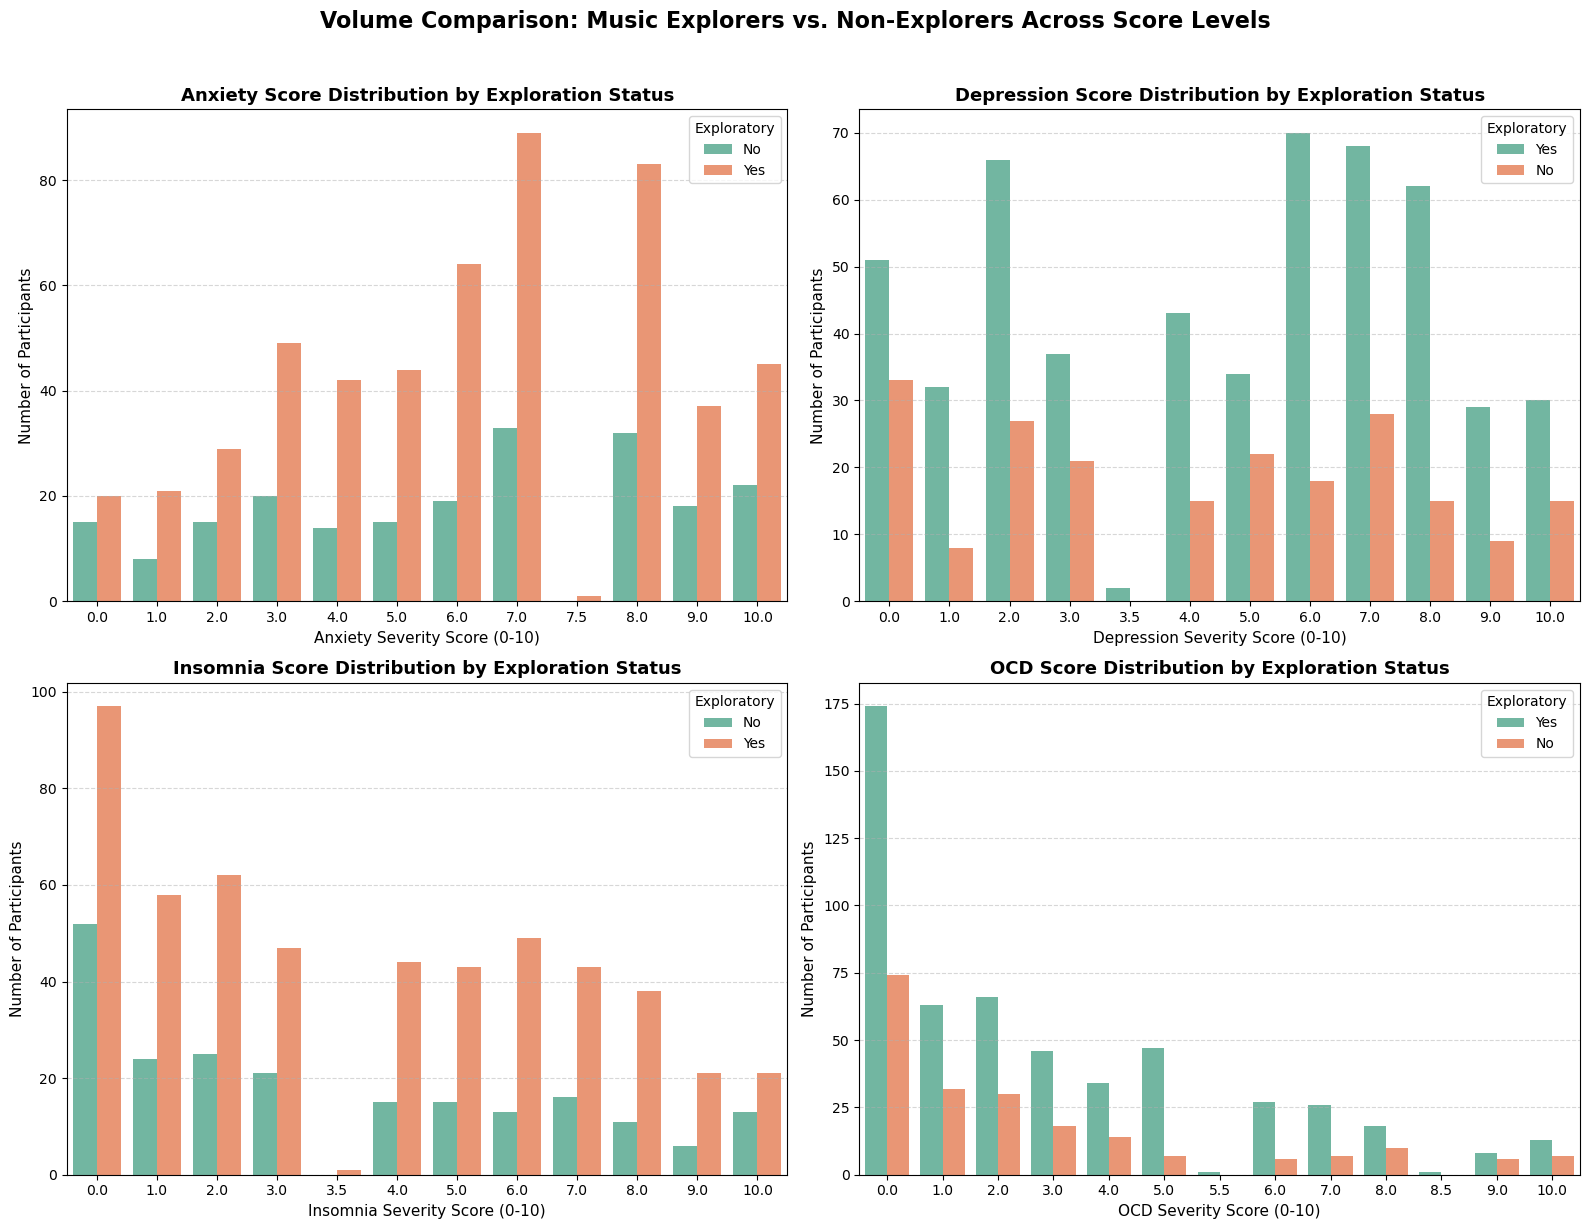

In [10]:
# 2. Setup a 2x2 grid for the bar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# List of the individual mental health scores
mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

# 3. Plot a grouped count bar chart for each disorder
for i, col in enumerate(mh_columns):
    sns.countplot(
        data=df,
        x=col,
        hue='Exploratory',
        palette='Set2',
        ax=axes[i]
    )
    
    # Custom labels and styling
    axes[i].set_title(f'{col} Score Distribution by Exploration Status', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'{col} Severity Score (0-10)', fontsize=11)
    axes[i].set_ylabel('Number of Participants', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(title='Exploratory')

# 4. Clean layout and save
plt.suptitle('Volume Comparison: Music Explorers vs. Non-Explorers Across Score Levels', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('individual_disorder_counts_bar.png', dpi=300, bbox_inches='tight')

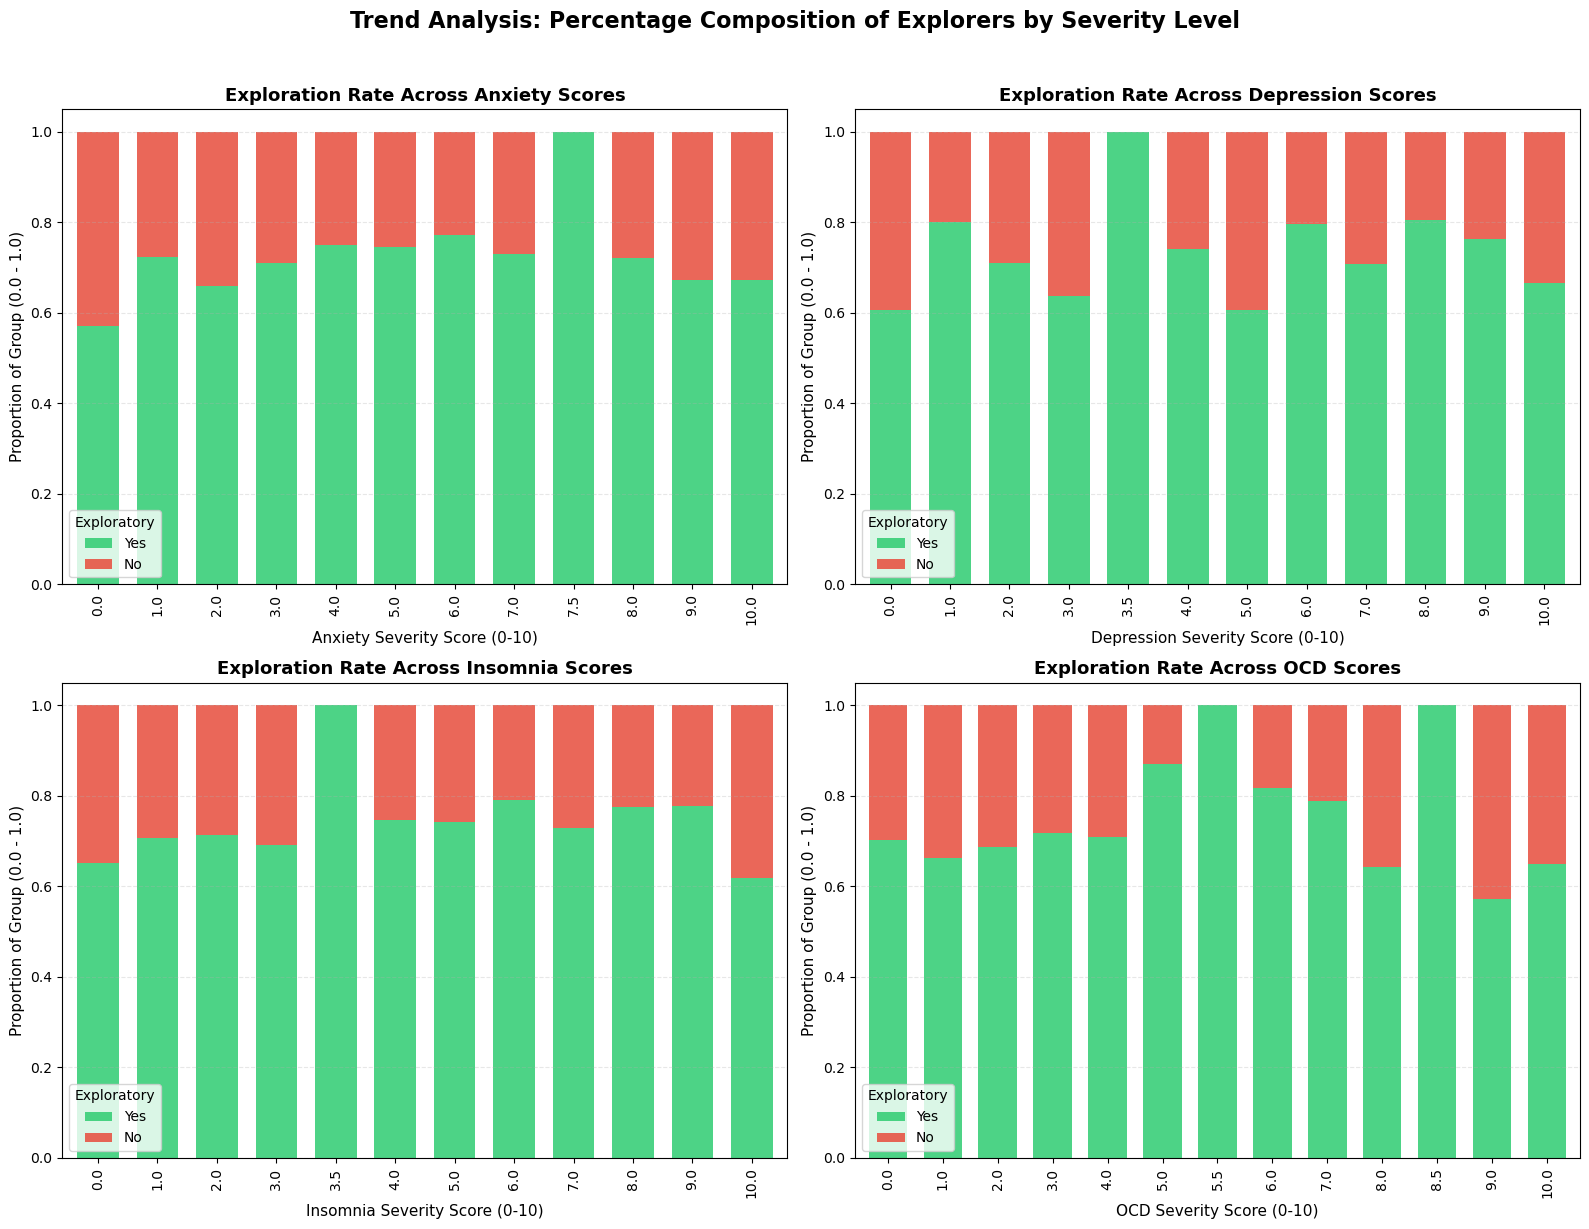

In [11]:


# 2. Setup a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

# 3. Calculate percentages and plot stacked bars
for i, col in enumerate(mh_columns):
    # Cross-tabulate to get percentages (0.0 to 1.0) for each row
    percentage_df = pd.crosstab(df[col], df['Exploratory'], normalize='index')
    
    # Explicitly reorder columns so 'Yes' is first (Green) and 'No' is second (Red)
    # This prevents the colors from flipping between subplots
    percentage_df = percentage_df.reindex(columns=['Yes', 'No'], fill_value=0)
    
    # Plot as a stacked bar chart
    percentage_df.plot(
        kind='bar', 
        stacked=True, 
        ax=axes[i], 
        color=['#2ecc71', '#e74c3c'],  # Yes = Green, No = Red
        alpha=0.85,
        width=0.7
    )
    
    # Custom labels and styling
    axes[i].set_title(f'Exploration Rate Across {col} Scores', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'{col} Severity Score (0-10)', fontsize=11)
    axes[i].set_ylabel('Proportion of Group (0.0 - 1.0)', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    axes[i].legend(title='Exploratory', loc='lower left')

# 4. Clean layout and save
plt.suptitle('Trend Analysis: Percentage Composition of Explorers by Severity Level', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('individual_disorder_proportions_bar_fixed.png', dpi=300, bbox_inches='tight')

From this visualization it seems like there is not much statistical significance, and there doesn't seem to be a lot of variation. I would be interested in teh future in maybe just going back to look at the data and seeing if older people are less willing to explore new music (I would have to argue yes lol).

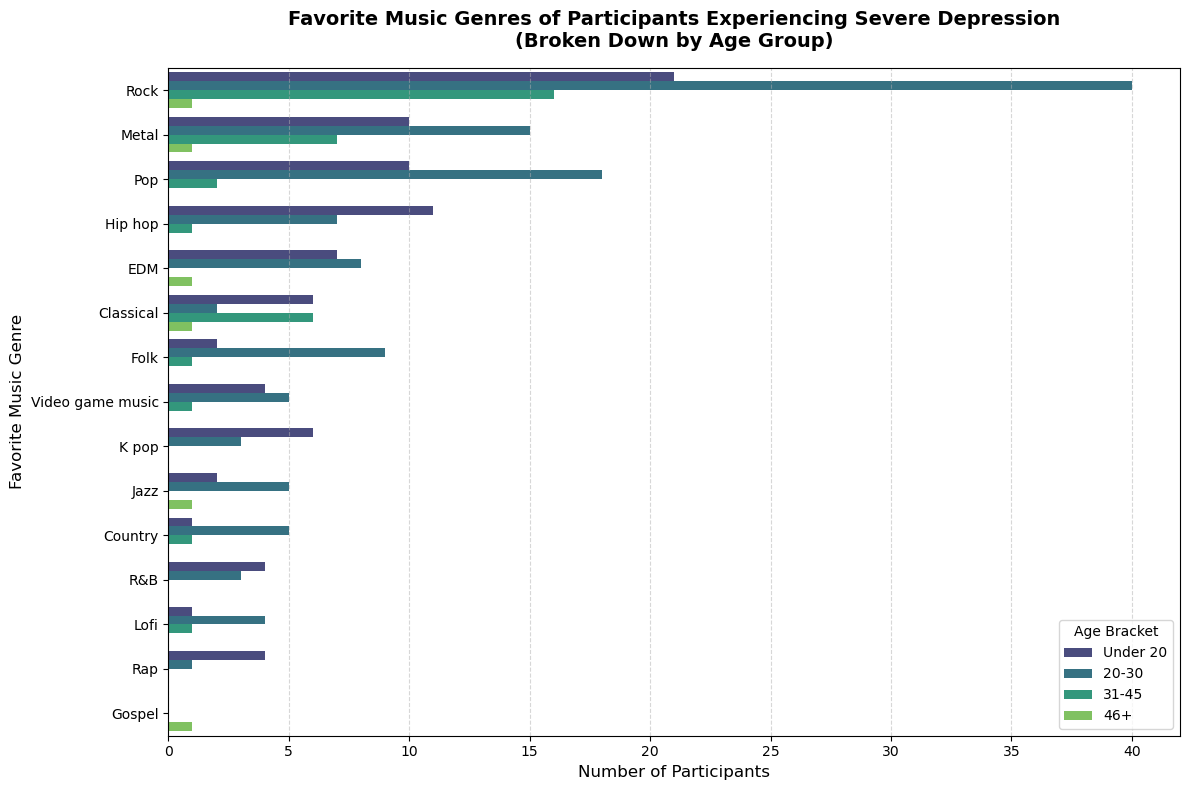

In [14]:
#question to pose do people of different age groups struggling wiht the same mental health disorder lsiten to the same kind of music?


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
FILE_PATH = "../../data/01-interim/MxMH_Survey_cleaned.csv"
df = pd.read_csv(FILE_PATH)

# 2. Create distinct Age Groups to make categorical comparison possible
age_bins = [0, 19, 30, 45, 100]
age_labels = ['Under 20', '20-30', '31-45', '46+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 3. Filter for participants "struggling" with a specific disorder 
# Let's use Depression as our primary case study (Severity score >= 7 out of 10)
struggling_df = df[df['Depression'] >= 7].dropna(subset=['Age Group', 'Fav genre'])

# 4. Set up the visualization canvas
plt.figure(figsize=(12, 8))

# Countplot automatically tabulates how many people in each Age Group prefer each genre
sns.countplot(
    data=struggling_df,
    y='Fav genre',
    hue='Age Group',
    palette='viridis',
    order=struggling_df['Fav genre'].value_counts().index # Sorts genres by overall popularity
)

# 5. Labels and clean formatting
plt.title('Favorite Music Genres of Participants Experiencing Severe Depression\n(Broken Down by Age Group)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Participants', fontsize=12)
plt.ylabel('Favorite Music Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Age Bracket', loc='lower right')

# 6. Save the figure
plt.tight_layout()
plt.savefig('genre_by_age_group_mental_health.png', dpi=300)


I like the detail but -- I think I need to obciously consider the other mental health groups, and additionally I think we should hone in on under 20 to 20-30 only because they are the largest groups and I might be missrepresenting the other groups...

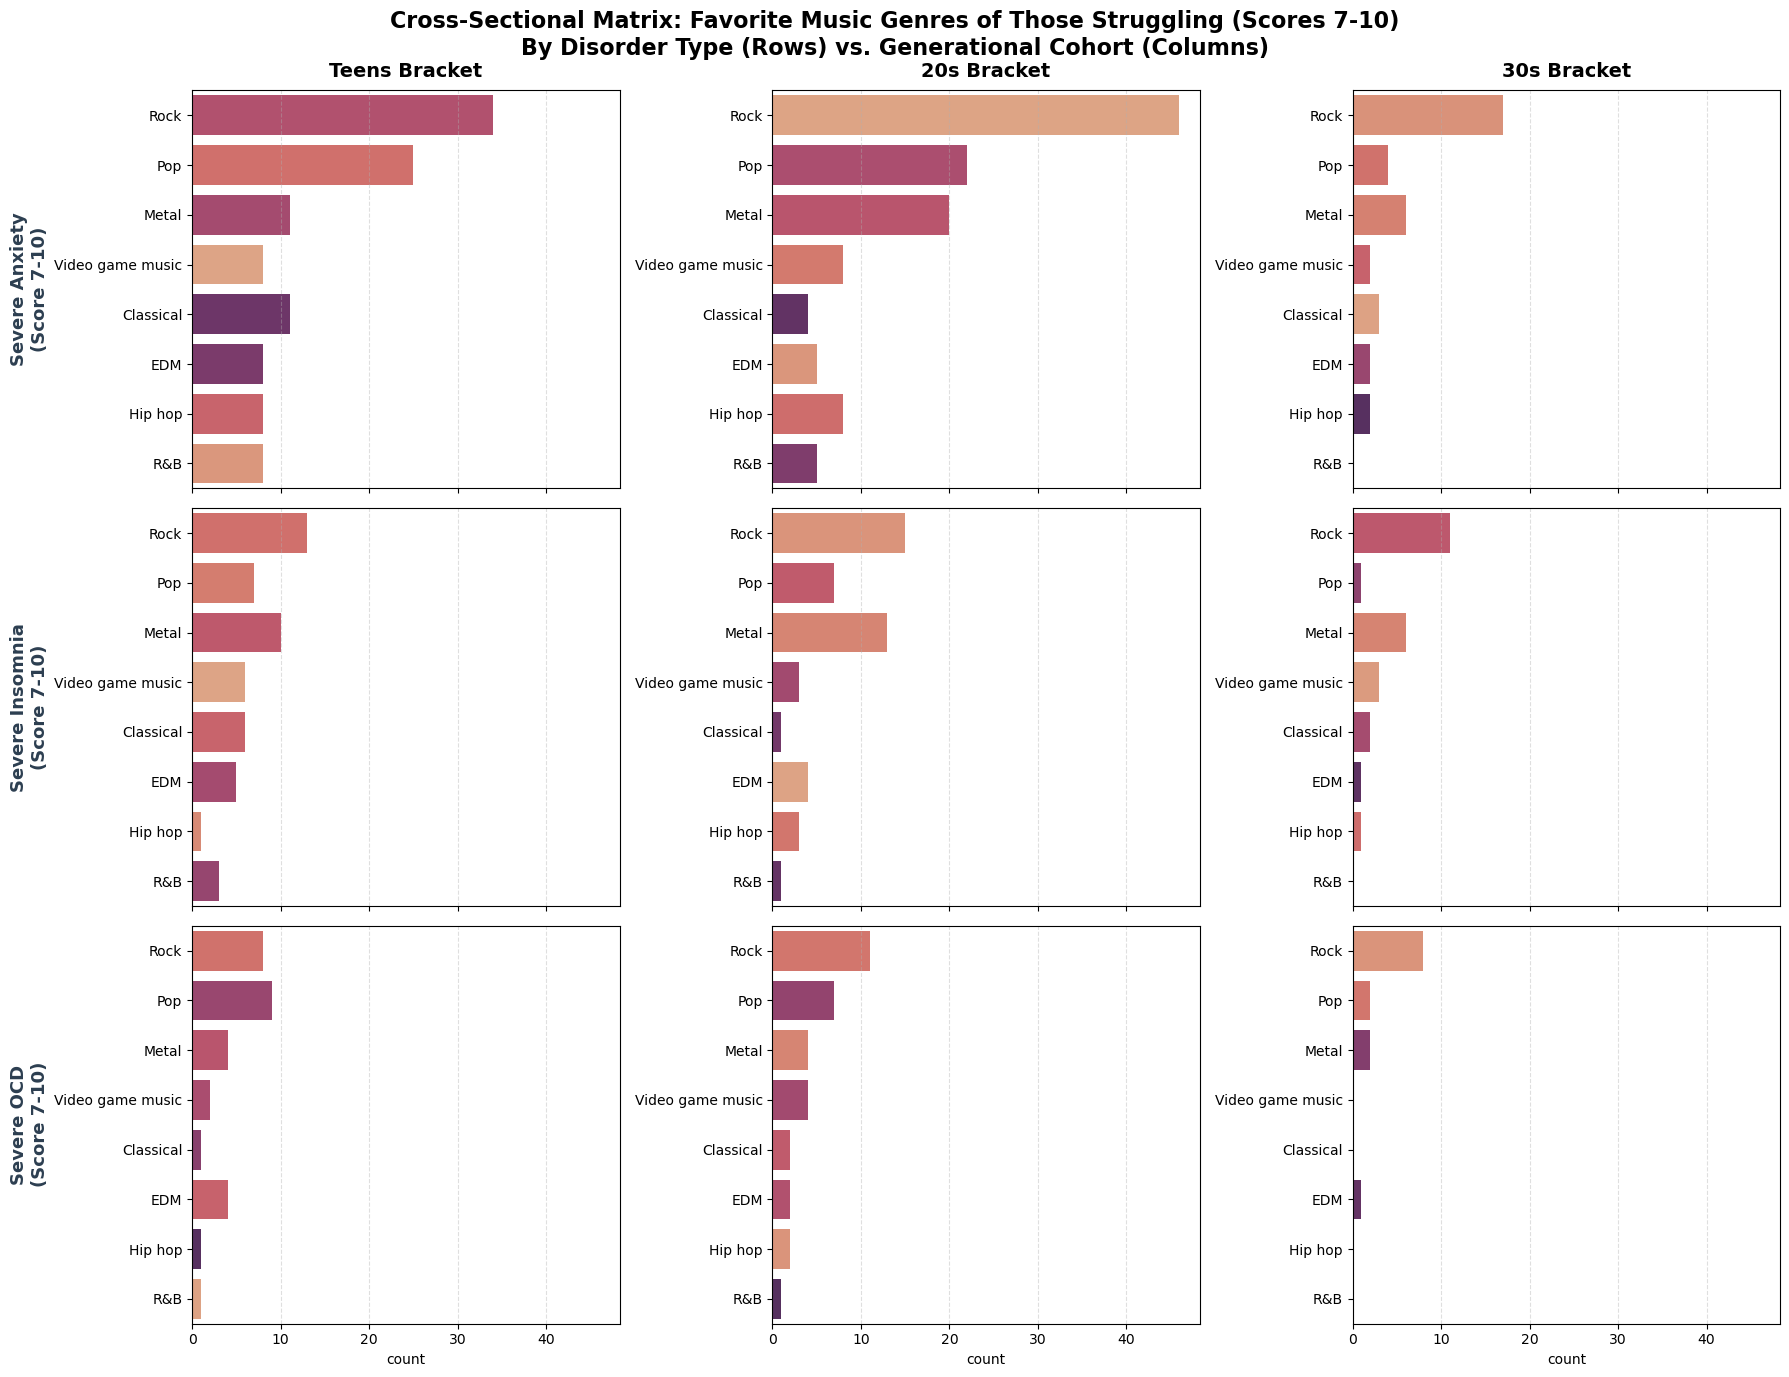

In [15]:


# Drop missing values in the primary structural features
df = df.dropna(subset=['Age', 'Fav genre'])

# 2. Filter for Teens, 20s, and 30s only (Ages 13 to 39 inclusive)
df = df[(df['Age'] >= 13) & (df['Age'] < 40)]

# Create clear categorical bins for the columns
age_bins = [12, 19, 29, 39]
age_labels = ['Teens', '20s', '30s']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 3. Define Matrix Layout Dimensions
disorders = ['Anxiety', 'Insomnia', 'OCD']
nrows = len(disorders)   # 3 rows
ncols = len(age_labels)  # 3 columns

# Create the 3x3 subplot grid matrix, sharing the X-axis for straightforward volume comparison
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14), sharex=True)

# Determine the global order of genres based on popularity to keep Y-axes standard
genre_order = df['Fav genre'].value_counts().index[:8]  # Shows the top 8 genres for cleaner reading

# 4. Populate the Matrix
for r, disorder in enumerate(disorders):
    for c, age_grp in enumerate(age_labels):
        
        # Filter data for this specific matrix cell: High severity (>= 7) AND specific age group
        cell_df = df[(df[disorder] >= 7) & (df['Age Group'] == age_grp)]
        ax = axes[r, c]
        
        # Plot horizontal count bars
        sns.countplot(
            data=cell_df,
            y='Fav genre',
            ax=ax,
            order=genre_order,
            palette='flare',
            hue='Fav genre',
            legend=False
        )
        
        # Set titles exclusively for the top row to act as column headers
        if r == 0:
            ax.set_title(f'{age_grp} Bracket', fontsize=14, fontweight='bold', pad=10)
            
        # Set text labels exclusively for the leftmost column to act as row headers
        if c == 0:
            ax.set_ylabel(f'Severe {disorder}\n(Score 7-10)', fontsize=13, fontweight='bold', color='#2c3e50')
        else:
            ax.set_ylabel('') # Clear y-axis label for inside plots to avoid clutter
            
        # Clean up tick layouts
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

# 5. Global formatting and saving
plt.suptitle('Cross-Sectional Matrix: Favorite Music Genres of Those Struggling (Scores 7-10)\nBy Disorder Type (Rows) vs. Generational Cohort (Columns)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the matrix image
plt.savefig('disorder_age_genre_matrix.png', dpi=300, bbox_inches='tight')

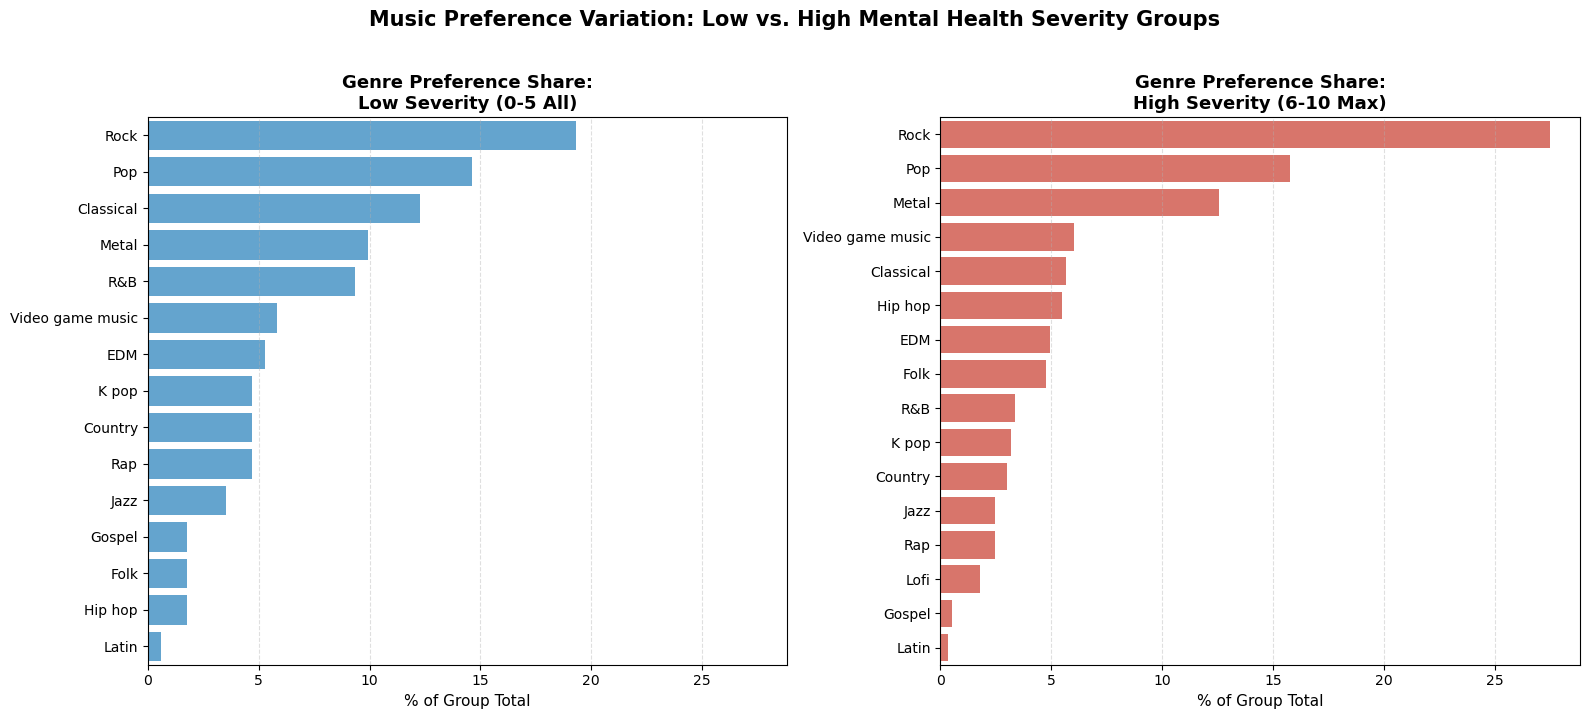

In [19]:
#is there a lot of variation amongst people who documented low (0-5 for all mental health conditions) in terms fo their music preferences
#in contrast is there variation for the 5-10 group? or as much variation?
#how similar is the variation 


# 1. Load the dataset
FILE_PATH = "../../data/01-interim/MxMH_Survey_cleaned.csv"
df = pd.read_csv(FILE_PATH)
df = df.dropna(subset=['Fav genre'])

# 2. Group people by overall condition severity
mh_columns = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
# Find the highest score an individual has among any of the 4 conditions
df['Max Severity'] = df[mh_columns].max(axis=1)

# Categorize into Low (0-5 across the board) vs High (6-10 in at least one thing)
df['Severity Group'] = df['Max Severity'].apply(lambda x: 'Low Severity (0-5 All)' if x <= 5 else 'High Severity (6-10 Max)')

# 3. Setup side-by-side plots for visual variance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
groups = ['Low Severity (0-5 All)', 'High Severity (6-10 Max)']
colors = ['#3498db', '#e74c3c'] # Blue for low distress, Red for high distress

for i, grp in enumerate(groups):
    subset = df[df['Severity Group'] == grp]
    
    # Calculate relative percentage share of each genre within this specific group
    genre_percentages = subset['Fav genre'].value_counts(normalize=True) * 100
    
    sns.barplot(
        x=genre_percentages.values,
        y=genre_percentages.index,
        ax=axes[i],
        color=colors[i],
        alpha=0.85
    )
    
    axes[i].set_title(f'Genre Preference Share:\n{grp}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('% of Group Total', fontsize=11)
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.4)

# 4. Save the figure
plt.suptitle('Music Preference Variation: Low vs. High Mental Health Severity Groups', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('genre_variance_low_vs_high_severity.png', dpi=300, bbox_inches='tight')

/var/folders/bk/n4l3gsw53vl53fzgz77x63x80000gn/T/ipykernel_882/3329629160.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


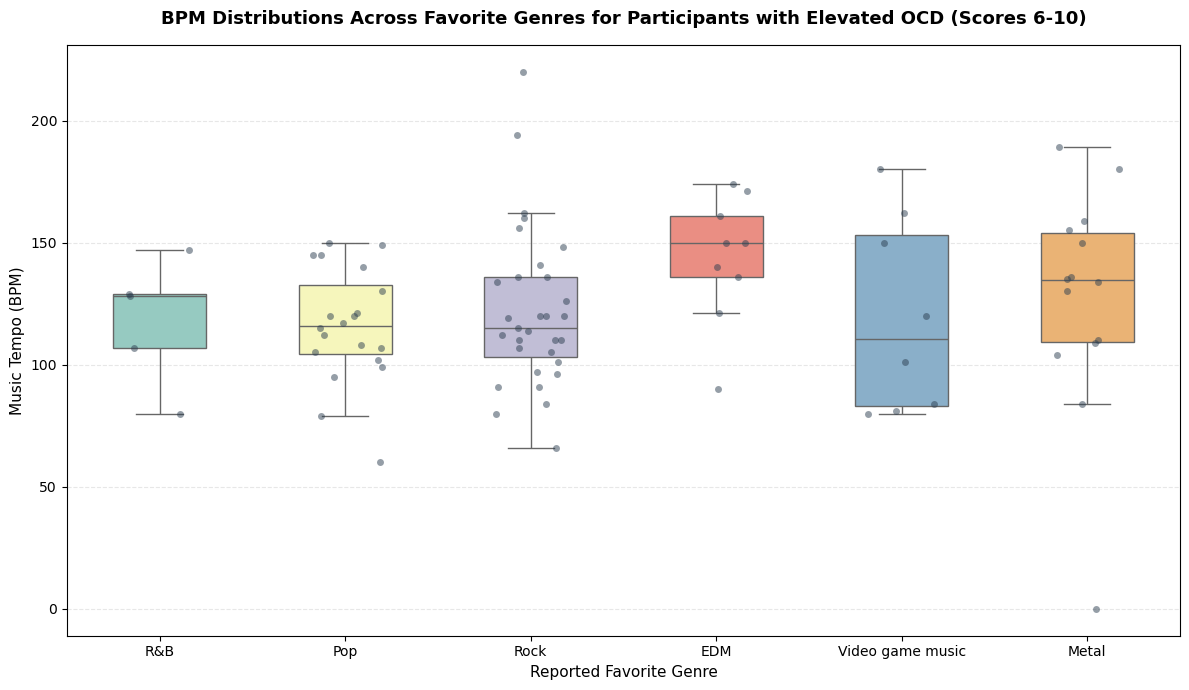

In [20]:
# do people have a preference for music of a certain bpm more than a genre and what does this look like for given mental health groups
# I feel like people with OCD will have a big prefernce in terms of bpm - but is it more than their preference of genre?


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
FILE_PATH = "../../data/01-interim/MxMH_Survey_cleaned.csv"
df = pd.read_csv(FILE_PATH)

# Clean out missing BPM data (since BPM has missing entries in this dataset)
df = df.dropna(subset=['BPM', 'Fav genre'])

# Filter for participants experiencing moderate-to-severe OCD symptoms (Score >= 6)
ocd_df = df[df['OCD'] >= 6]

# Filter down to top-occurring favorite genres in this filtered group to keep it clean
top_genres = ocd_df['Fav genre'].value_counts().index[:6]
ocd_filtered = ocd_df[ocd_df['Fav genre'].isin(top_genres)]

# 2. Generate the variation plot
plt.figure(figsize=(12, 7))

# Underlay the boxplot to view quartile ranges/medians
sns.boxplot(
    data=ocd_filtered,
    x='Fav genre',
    y='BPM',
    palette='Set3',
    width=0.5,
    fliersize=0 # Hides default outliers so they don't double-plot with the stripplot
)

# Overlay individual raw data points to see cluster density/volume
sns.stripplot(
    data=ocd_filtered,
    x='Fav genre',
    y='BPM',
    color='#2c3e50',
    size=5,
    alpha=0.5,
    jitter=0.2
)

# 3. Labeling and Formatting
plt.title('BPM Distributions Across Favorite Genres for Participants with Elevated OCD (Scores 6-10)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Reported Favorite Genre', fontsize=11)
plt.ylabel('Music Tempo (BPM)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Save the figure
plt.tight_layout()
plt.savefig('ocd_genre_vs_bpm_variance.png', dpi=300)


okay I realized that I dont have a gage of what bpm looks like on average so I need to do that seperate!

In [21]:


# Drop rows missing BPM data
df_bpm = df.dropna(subset=['BPM'])

print("--- AVERAGE BPM BREAKDOWN (SEVERITY >= 6) ---")

# 1. Compute for Elevated OCD Group
ocd_high = df_bpm[df_bpm['OCD'] >= 6]
print(f"Elevated OCD (Score 6-10) Average BPM: {ocd_high['BPM'].mean():.2f} BPM (n = {len(ocd_high)})")

# 2. Compute for Comparison Groups (Severe Anxiety, Depression, Insomnia)
for condition in ['Anxiety', 'Depression', 'Insomnia']:
    condition_high = df_bpm[df_bpm[condition] >= 6]
    print(f"Elevated {condition} (Score 6-10) Average BPM: {condition_high['BPM'].mean():.2f} BPM (n = {len(condition_high)})")

print("\n--- GENERAL BASELINES ---")
# 3. Baseline comparison: High OCD vs Everyone Else
non_ocd_high = df_bpm[df_bpm['OCD'] < 6]
print(f"Low/No OCD (Score 0-5) Average BPM: {non_ocd_high['BPM'].mean():.2f} BPM")
print(f"Entire Dataset Global Average BPM: {df_bpm['BPM'].mean():.2f} BPM")

--- AVERAGE BPM BREAKDOWN (SEVERITY >= 6) ---
Elevated OCD (Score 6-10) Average BPM: 121.91 BPM (n = 113)
Elevated Anxiety (Score 6-10) Average BPM: 123.48 BPM (n = 383)
Elevated Depression (Score 6-10) Average BPM: 3322383.40 BPM (n = 301)
Elevated Insomnia (Score 6-10) Average BPM: 4854493.19 BPM (n = 206)

--- GENERAL BASELINES ---
Low/No OCD (Score 0-5) Average BPM: 1938108.01 BPM
Entire Dataset Global Average BPM: 1589948.34 BPM


nice so there appears to be some horseshit numbers! 300bpm is like almost unlistenable so i'm going to go on a whim heer and say maybe this is abd data and try to limit the bpm to 300 max?

In [25]:
import pandas as pd



# 2. DROP MISSING VALUES AND INSANE OUTLIERS
# This removes both the blank rows and the multi-million joke entries safely
df_clean = df.dropna(subset=['BPM'])
df_clean = df_clean[(df_clean['BPM'] >= 20) & (df_clean['BPM'] <= 300)]

print("==================================================")
print("     CLEANED BPM ANALYSIS (OUTLIERS REMOVED)     ")
print("==================================================")

# 3. FOCUS TARGET: Elevated OCD Group
high_ocd_condition = df_clean['OCD'] >= 6
high_ocd_group = df_clean[high_ocd_condition]
print(f" Elevated OCD (Scores 6-10): {high_ocd_group['BPM'].mean():.2f} BPM  (n = {len(high_ocd_group)})")

print("\n--- POOLED BASELINE ---")
# 4. COMPLEMENT GROUP: Everyone else pooled together (Low OCD + High anxiety/dep without high OCD, etc.)
everyone_else_group = df_clean[~high_ocd_condition]
print(f" ALL OTHER PARTICIPANTS POOLED: {everyone_else_group['BPM'].mean():.2f} BPM  (n = {len(everyone_else_group)})")

print("\n--- INDIVIDUAL SEVERE CONDITION BREAKDOWNS ---")
# 5. Severe categories for comparisons
for condition in ['Anxiety', 'Depression', 'Insomnia']:
    severe_subset = df_clean[df_clean[condition] >= 6]
    print(f"  Elevated {condition:10} (Scores 6-10): {severe_subset['BPM'].mean():.2f} BPM  (n = {len(severe_subset)})")

print("\n--- INDIVIDUAL LOW/MODERATE SEVERITY BREAKDOWNS ---")
# 6. Low/Moderate categories for full context
for condition in ['OCD', 'Anxiety', 'Depression', 'Insomnia']:
    low_subset = df_clean[df_clean[condition] <= 5]
    print(f"  Low/Mod {condition:11} (Scores 0-5):  {low_subset['BPM'].mean():.2f} BPM  (n = {len(low_subset)})")

print("==================================================")

     CLEANED BPM ANALYSIS (OUTLIERS REMOVED)     
 Elevated OCD (Scores 6-10): 124.11 BPM  (n = 111)

--- POOLED BASELINE ---
 ALL OTHER PARTICIPANTS POOLED: 123.48 BPM  (n = 511)

--- INDIVIDUAL SEVERE CONDITION BREAKDOWNS ---
  Elevated Anxiety    (Scores 6-10): 124.76 BPM  (n = 379)
  Elevated Depression (Scores 6-10): 124.23 BPM  (n = 296)
  Elevated Insomnia   (Scores 6-10): 126.06 BPM  (n = 203)

--- INDIVIDUAL LOW/MODERATE SEVERITY BREAKDOWNS ---
  Low/Mod OCD         (Scores 0-5):  123.55 BPM  (n = 510)
  Low/Mod Anxiety     (Scores 0-5):  121.77 BPM  (n = 243)
  Low/Mod Depression  (Scores 0-5):  123.02 BPM  (n = 326)
  Low/Mod Insomnia    (Scores 0-5):  122.39 BPM  (n = 419)


awesome glad to see this is another nothing burger 

BPM is remarkably similar to the All Other Participants Pooled average, it proves that people with OCD don't necessarily listen to inherently faster or slower music on average

but maybe there is more clinging to specific numbers by genre that i did'nt think to analyze before so now I should look at what the varaition in otehr plots appears to be!

/var/folders/bk/n4l3gsw53vl53fzgz77x63x80000gn/T/ipykernel_882/2349410627.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/bk/n4l3gsw53vl53fzgz77x63x80000gn/T/ipykernel_882/2349410627.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/bk/n4l3gsw53vl53fzgz77x63x80000gn/T/ipykernel_882/2349410627.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/bk/n4l3gsw53vl53fzgz77x63x80000gn/T/ipykernel_882/2349410627.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

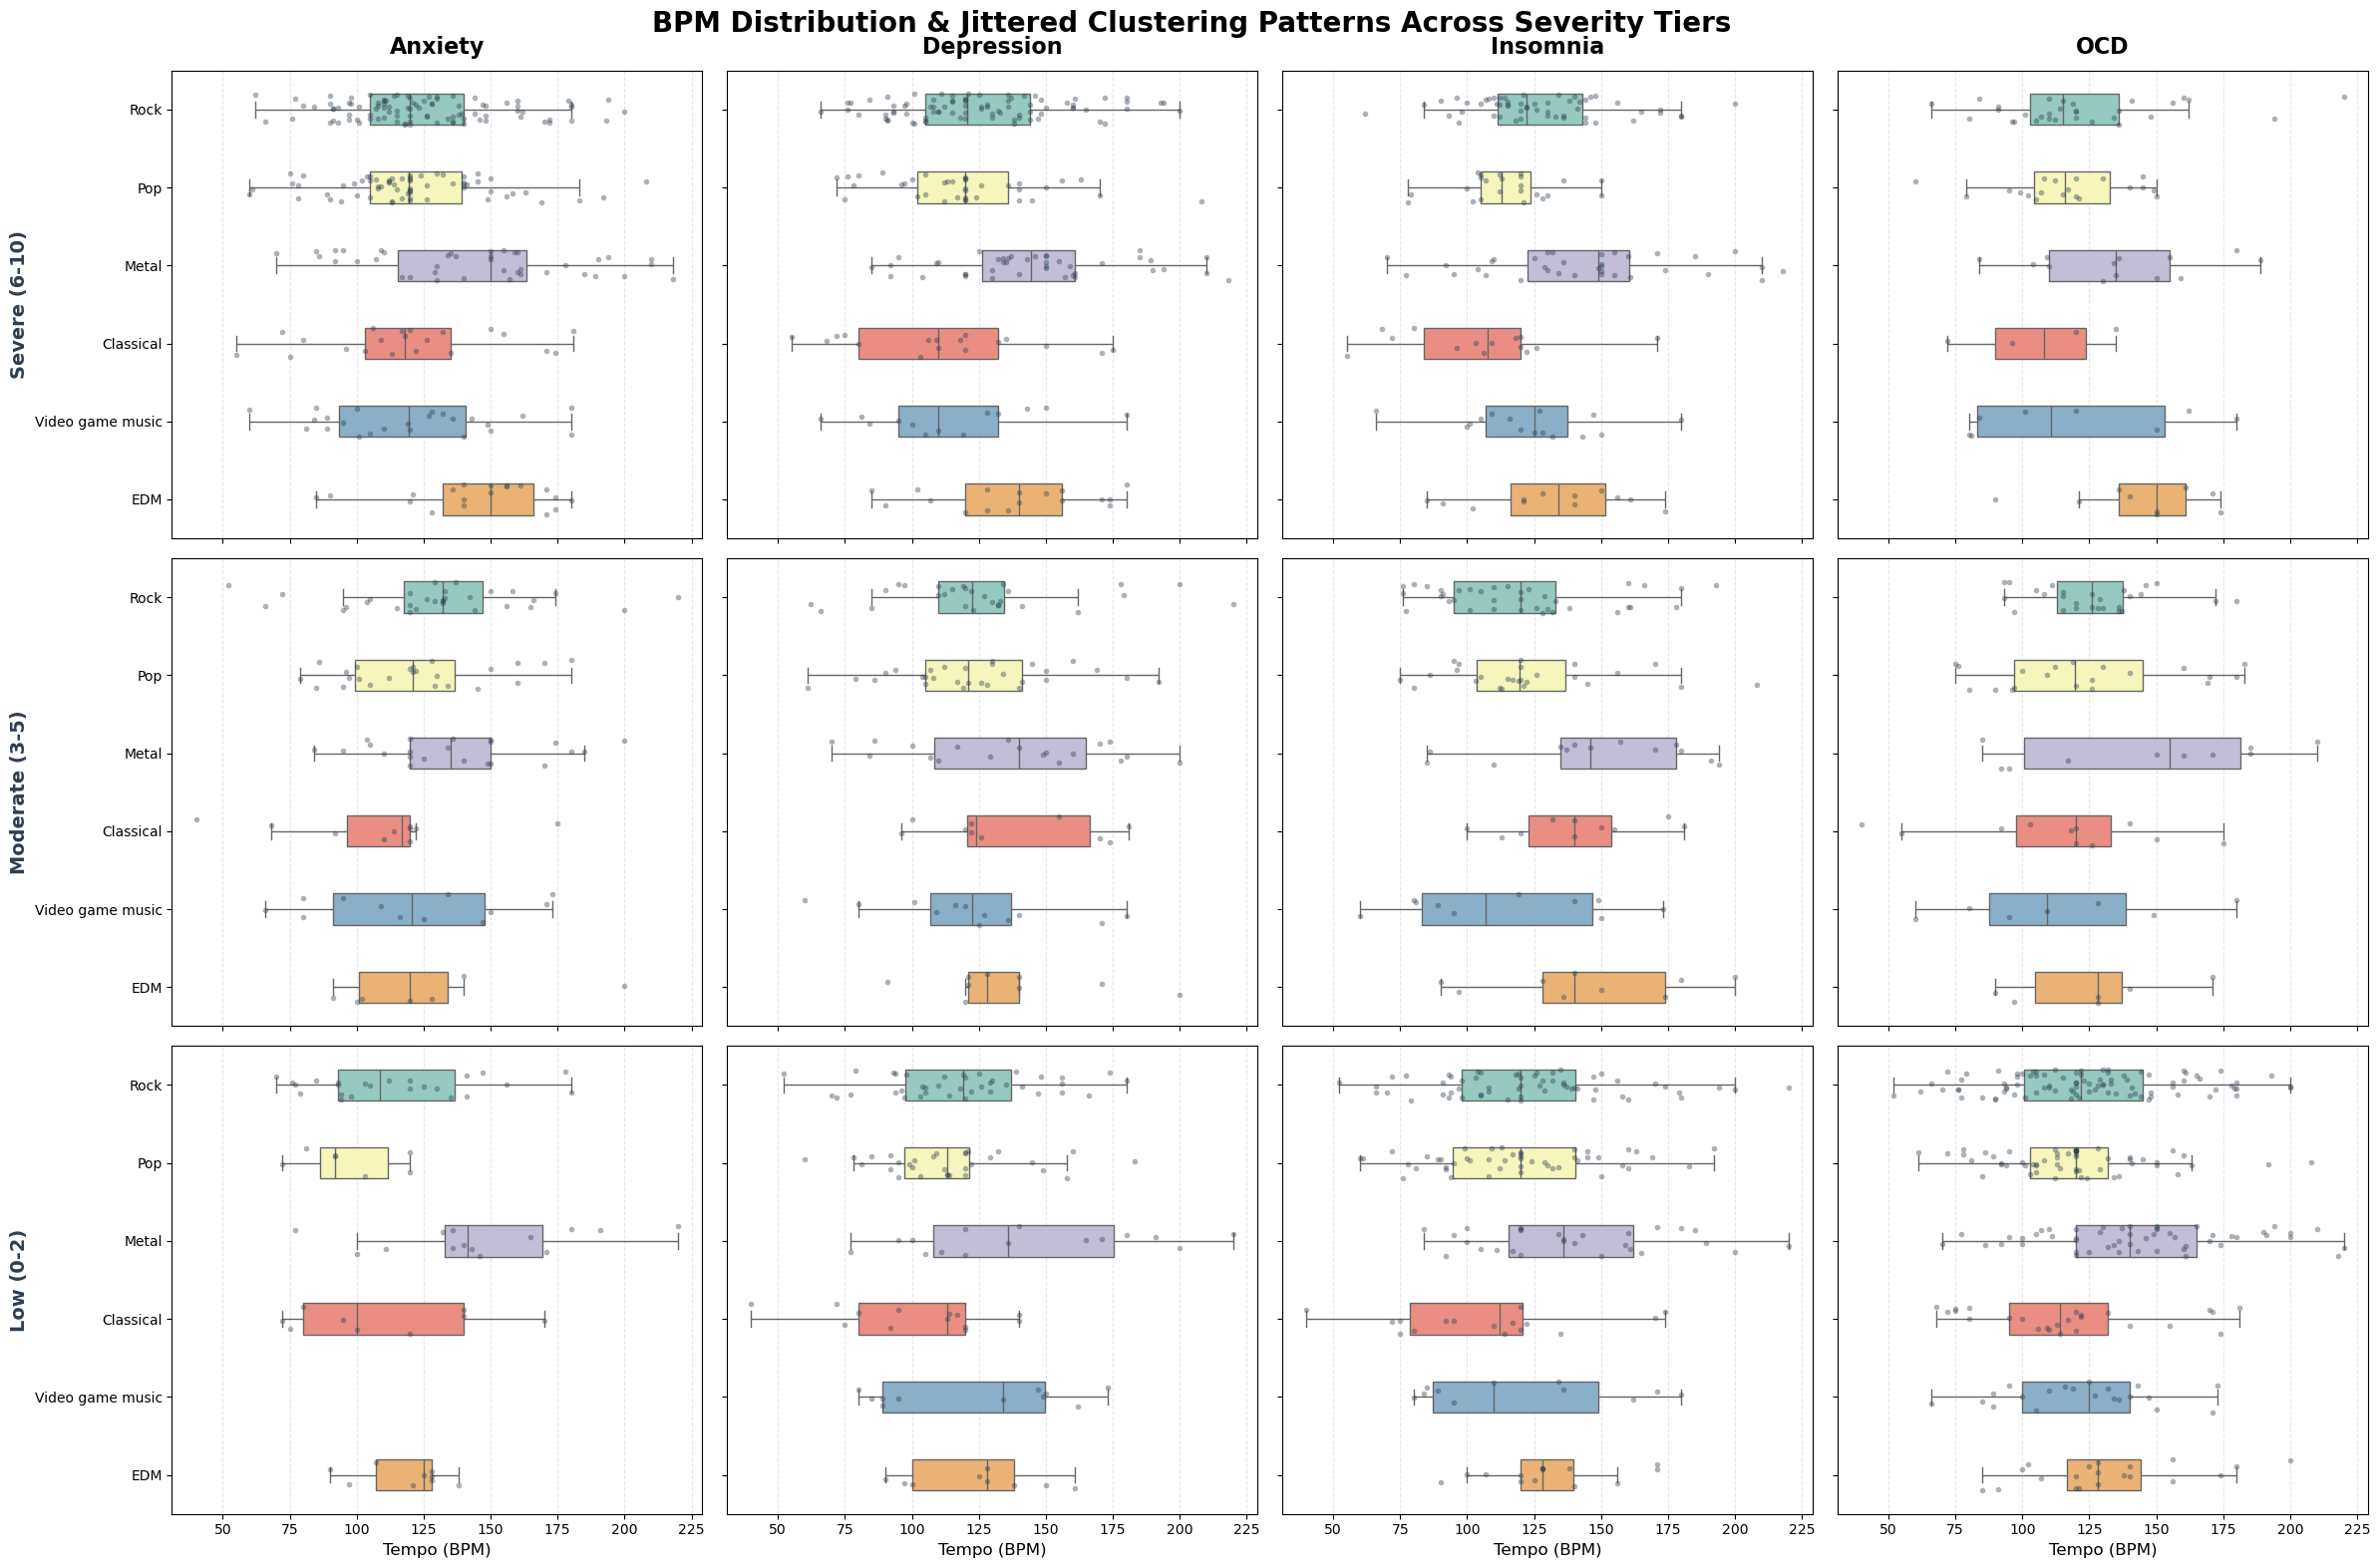

In [26]:


df_clean = df.dropna(subset=['BPM', 'Fav genre'])
# Strip out joke entries to preserve scale uniformity across the grid
df_clean = df_clean[(df_clean['BPM'] >= 20) & (df_clean['BPM'] <= 300)]

# Standardize the Y-axis categories by focusing on the top overall genres
top_genres = df_clean['Fav genre'].value_counts().index[:6]
df_matrix = df_clean[df_clean['Fav genre'].isin(top_genres)]

# 2. Define our matrix dimensions
conditions = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
severity_labels = ['Severe (6-10)', 'Moderate (3-5)', 'Low (0-2)']

nrows = len(severity_labels) # 3
ncols = len(conditions)      # 4

# sharey=True forces every single graph to use the exact same genre listing on the Y-axis
# sharex=True keeps the 20-300 BPM scale completely aligned for instant visual comparison
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 16), sharex=True, sharey=True)

# 3. Populate the Matrix Grid
for r, sev in enumerate(severity_labels):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        
        # Filter the data for this exact cell based on severity tier definitions
        if r == 0:     # Severe
            cell_df = df_matrix[df_matrix[cond] >= 6]
        elif r == 1:   # Moderate / Average
            cell_df = df_matrix[(df_matrix[cond] >= 3) & (df_matrix[cond] <= 5)]
        else:          # Low
            cell_df = df_matrix[df_matrix[cond] <= 2]
            
        # If a cell has data, plot the distribution
        if not cell_df.empty:
            # Boxplot for the core distribution structure
            sns.boxplot(
                data=cell_df,
                y='Fav genre',
                x='BPM',
                ax=ax,
                order=top_genres,
                palette='Set3',
                width=0.4,
                fliersize=0
            )
            # Stripplot overlay to reveal raw cluster density
            sns.stripplot(
                data=cell_df,
                y='Fav genre',
                x='BPM',
                ax=ax,
                order=top_genres,
                color='#2c3e50',
                size=4,
                alpha=0.4,
                jitter=0.2
            )
            
        # --- Metadata and Layout Cleanup ---
        # Set column titles only on the very top row
        if r == 0:
            ax.set_title(cond, fontsize=16, fontweight='bold', pad=12)
            
        # Set row headers only on the leftmost column
        if c == 0:
            ax.set_ylabel(sev, fontsize=14, fontweight='bold', color='#2c3e50')
        else:
            ax.set_ylabel('')
            
        # Label the X-axis only on the bottom row to prevent text crowding
        if r == 2:
            ax.set_xlabel('Tempo (BPM)', fontsize=12)
        else:
            ax.set_xlabel('')
            
        ax.grid(axis='x', linestyle='--', alpha=0.3)

# 4. Super-title and export
plt.suptitle('BPM Distribution & Jittered Clustering Patterns Across Severity Tiers', 
             fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('mental_health_bpm_matrix.png', dpi=300, bbox_inches='tight')

In [28]:

df_clean = df[(df['BPM'] >= 20) & (df['BPM'] <= 300)]

# Isolate the BPM arrays for severe groups (Score >= 6)
severe_ocd_bpm = df_clean[df_clean['OCD'] >= 6]['BPM']
severe_anxiety_bpm = df_clean[df_clean['Anxiety'] >= 6]['BPM']
severe_depression_bpm = df_clean[df_clean['Depression'] >= 6]['BPM']
severe_insomnia_bpm = df_clean[df_clean['Insomnia'] >= 6]['BPM']

# Run Levene's test comparing all four spreads
stat, p_val = levene(severe_ocd_bpm, severe_anxiety_bpm, severe_depression_bpm, severe_insomnia_bpm)

print("============ VARIANCE SIGNIFICANCE TEST ============")
print(f"Levene's Test Statistic: {stat:.4f}")
print(f"p-value: {p_val:.5f}")

if p_val < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT! The differences in spread are real, even accounting for sample size.")
else:
    print("Result: NOT SIGNIFICANT. The tighter look of OCD is likely just noise from a smaller sample size.")
print("====================================================")

============ VARIANCE SIGNIFICANCE TEST ============
Levene's Test Statistic: 0.2776
p-value: 0.84159
Result: NOT SIGNIFICANT. The tighter look of OCD is likely just noise from a smaller sample size.


had to vibe code that ^ beacsue i had thought that ocd would have a greater spread bc it is often less reported so like the AI has written i hypothesized that is was only due to the small sample size ...

Multi-tasking split visualization successfully generated.


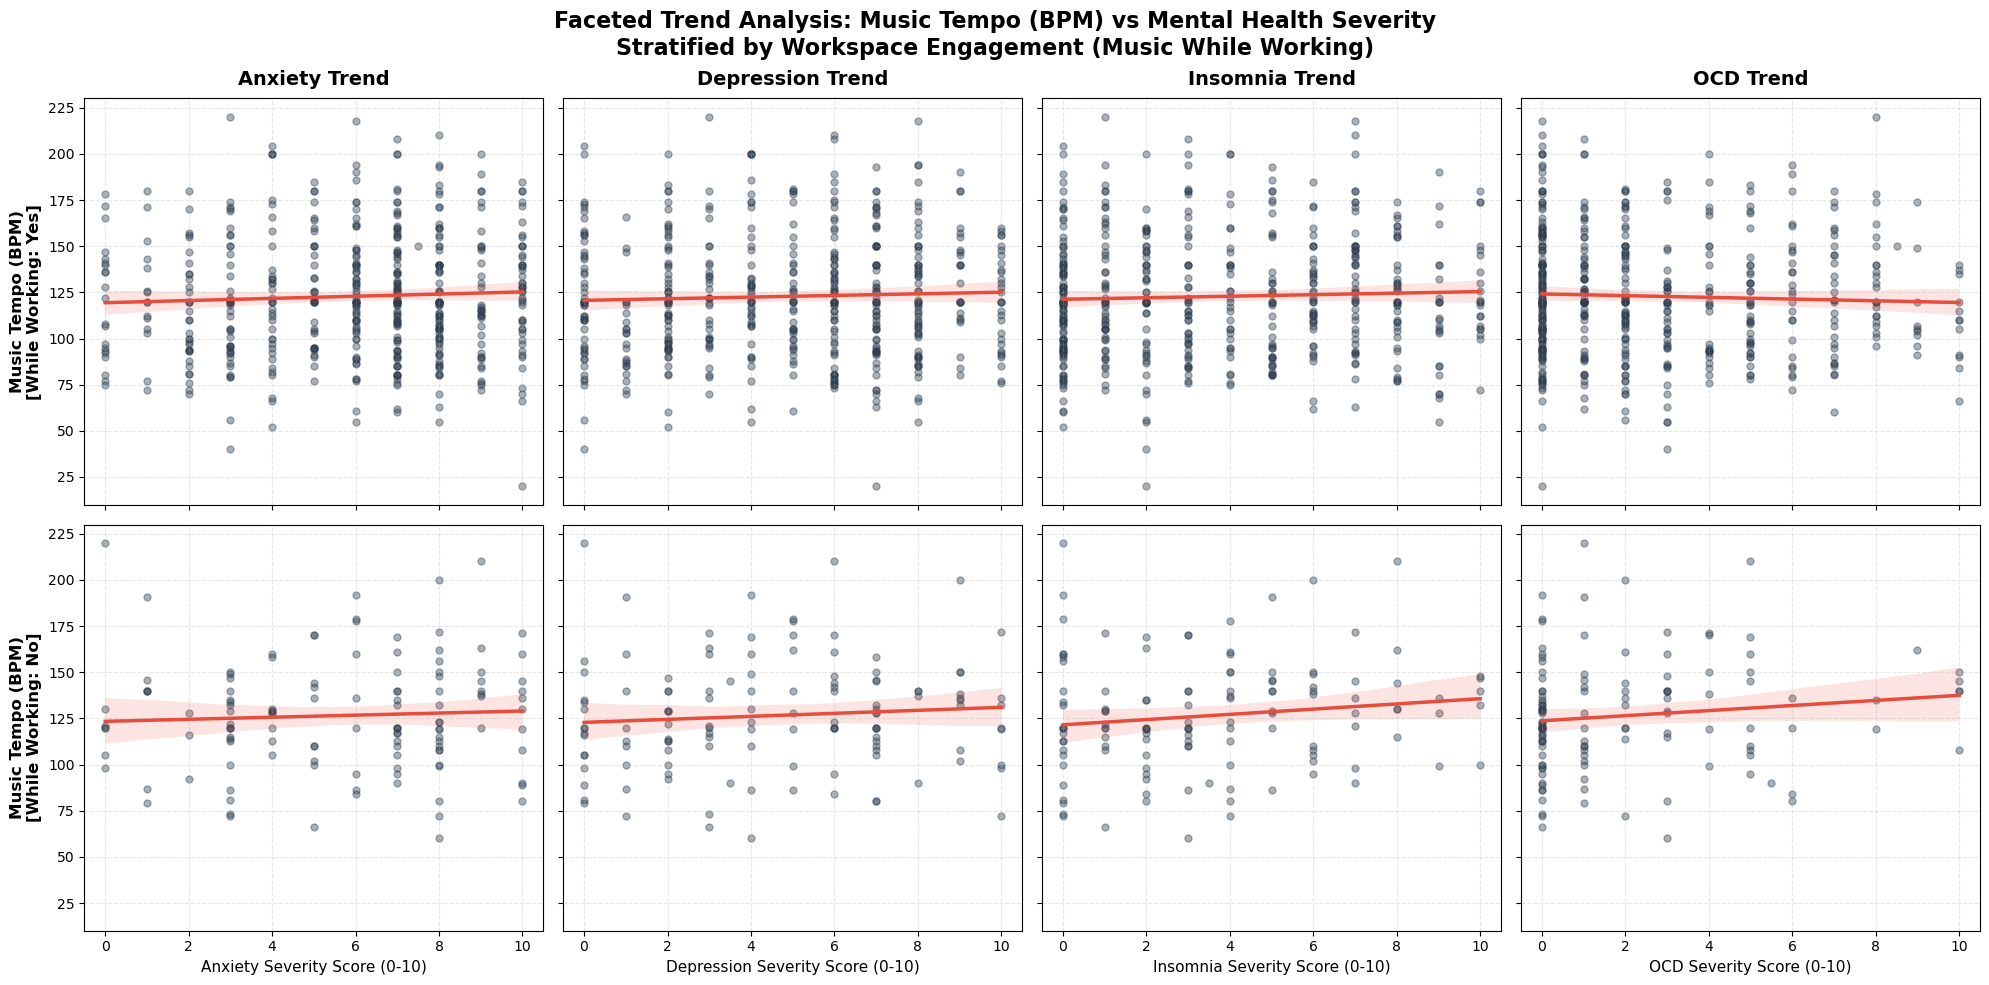

In [30]:


# Clean out rows missing our vital independent/dependent tracking metrics
df_clean = df.dropna(subset=['BPM', 'While working'])
df_clean = df_clean[(df_clean['BPM'] >= 20) & (df_clean['BPM'] <= 300)]
df_clean = df_clean[df_clean['While working'].isin(['Yes', 'No'])]

# 2. Establish Dimensions
conditions = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
work_statuses = ['Yes', 'No']

# Create a 2x4 grid sharing axes to keep the comparison scales unified
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=True, sharey=True)

# 3. Populate Grid
for r, status in enumerate(work_statuses):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        
        # Isolate target segment
        subset = df_clean[df_clean['While working'] == status]
        
        # Generate scatter plot with an overlaid linear regression trend line
        sns.regplot(
            data=subset,
            x=cond,
            y='BPM',
            ax=ax,
            scatter_kws={'alpha': 0.4, 'color': '#2c3e50', 's': 25},
            line_kws={'color': '#e74c3c', 'linewidth': 2.5}  # Sharp red trend line
        )
        
        # Grid line layouts for clarity
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Formatting Subplot Column Headers (Top Row Only)
        if r == 0:
            ax.set_title(f'{cond} Trend', fontsize=14, fontweight='bold', pad=10)
            
        # Formatting Subplot Row Labels (Left Column Only)
        if c == 0:
            ax.set_ylabel(f'Music Tempo (BPM)\n[While Working: {status}]', fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # Formatting Bottom Row X-Labels
        if r == 1:
            ax.set_xlabel(f'{cond} Severity Score (0-10)', fontsize=11)
        else:
            ax.set_xlabel('')

# 4. Super-title formatting and save
plt.suptitle('Faceted Trend Analysis: Music Tempo (BPM) vs Mental Health Severity\nStratified by Workspace Engagement (Music While Working)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('multitasking_bpm_regression_grid.png', dpi=300, bbox_inches='tight')
print("Multi-tasking split visualization successfully generated.")

As severity increases, people tend to listen to slightly faster music (higher BPM)
BUT the effect is tiny → lots of scatter = weak correlation

kinda just looks liek individaul preference effects taste in terms of bpm more than mental health

also I think the part of our hypothesis about productivity is kinda hard to properly gage with this data set. maybe adhd would have been a better affected group to look at, this kinda all seems like it is jsut going to prove our hypothesis wrong (not a bad thing) more so just kinda like a waste of time esp for such a small data set so it isn't like we could take our findings anywhere. I think rahter than genre we should have focused on something like individual artists and we would need data directly from a giant coorporation and like have to span multiple platforms and be incredibly invasive - no thanks i am not a data science person I'm going to school to not be evil! data science folk work to do the bidding of the upper class as they spy on us and pick a part every part of our lives until nothing is private, they actively arm them. I just want to build circuits...